In [5]:
!pip -q install rpy2

In [6]:
%load_ext rpy2.ipython

In [10]:
!apt-get update -qq
!apt-get install -y libfftw3-dev

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libfftw3-bin libfftw3-double3 libfftw3-long3 libfftw3-quad3 libfftw3-single3
Suggested packages:
  libfftw3-doc
The following NEW packages will be installed:
  libfftw3-bin libfftw3-dev libfftw3-double3 libfftw3-long3 libfftw3-quad3
  libfftw3-single3
0 upgraded, 6 newly installed, 0 to remove and 34 not upgraded.
Need to get 4,654 kB of archives.
After this operation, 24.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-double3 amd64 3.3.8-2ubuntu8 [770 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-long3 amd64 3.3.8-2ubuntu8 [335 kB]
Get:3 http://archive.ubuntu.com/ubun

In [11]:
%%R

install.packages("fftwtools", repos="https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/fftwtools_0.9-11.tar.gz'
Content type 'application/x-gzip' length 174321 bytes (170 KB)
downloaded 170 KB


The downloaded source packages are in
	‘/tmp/Rtmp1gKgNp/downloaded_packages’


In [12]:
%%R

BiocManager::install("EBImage", ask = FALSE, update = FALSE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)
Installing package(s) 'EBImage'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/EBImage_4.54.0.tar.gz'
Content type 'application/x-gzip' length 5462245 bytes (5.2 MB)
downloaded 5.2 MB


The downloaded source packages are in
	‘/tmp/Rtmp1gKgNp/downloaded_packages’


In [14]:
%%R

install.packages("keras", repos="https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘RcppTOML’, ‘here’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’

trying URL 'https://cloud.r-project.org/src/contrib/RcppTOML_0.2.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/here_1.0.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/config_0.3.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/tfautograph_0.3.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/reticulate_1.46.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/tensorflow_2.20.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/tfruns_1.5.4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/zeallot_0.2.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/keras_2.16.1.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp1gKgNp/downloaded_packages’


In [17]:
%%R

library(EBImage)
library(keras)

setwd('/content')

pics <- c(
  'p1.jpg', 'p2.jpg', 'p3.jpg',
  'p4.jpg', 'p5.jpg', 'p6.jpg',
  'c1.jpg', 'c2.jpg', 'c3.jpg',
  'c4.jpg', 'c5.jpg', 'c6.jpg'
)

mypic <- list()

for(i in 1:12) {
  mypic[[i]] <- readImage(pics[i])
}

length(mypic)

[1] 12


Image 
  colorMode    : Color 
  storage.mode : double 
  dim          : 281 180 3 
  frames.total : 3 
  frames.render: 1 

imageData(object)[1:5,1:6,1]
     [,1] [,2] [,3] [,4] [,5] [,6]
[1,]    1    1    1    1    1    1
[2,]    1    1    1    1    1    1
[3,]    1    1    1    1    1    1
[4,]    1    1    1    1    1    1
[5,]    1    1    1    1    1    1
List of 12
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:281, 1:180, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 281 180 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:272, 1:185, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 272 185 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:341, 1:148, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 341 148 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ 

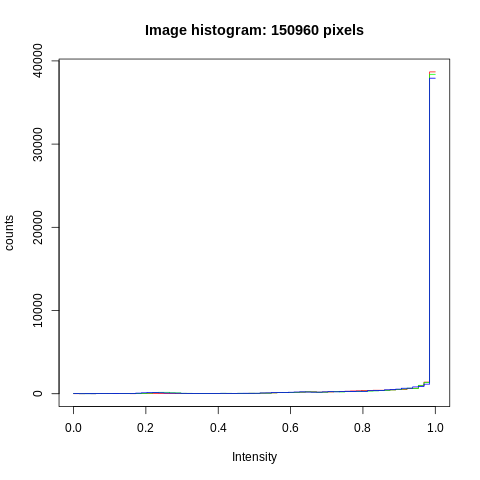

In [19]:
#explore
%%R

print(mypic[[1]])
display(mypic[[8]])
summary(mypic[[1]])
hist(mypic[[2]])
str(mypic)

In [20]:
%%R
#resize
for (i in 1:12){
    mypic[[i]] <- resize(mypic[[i]], 28,28)
}

In [21]:
%%R
#reshape
for (i in 1:12){
    mypic[[i]] <- array_reshape(mypic[[i]], c(28,28,3))
}

In [23]:
%%R

# Row Bind

trainx <- NULL

for(i in 1:5) {
  trainx <- rbind(trainx, mypic[[i]])
}

str(trainx)

testx <- rbind(mypic[[6]], mypic[[12]])

trainy <- c(0, 0, 0, 0, 0, 1, 1, 1, 1, 1)

testy <- c(0, 1)

 num [1:5, 1:2352] 1 1 1 0.26 0.49 ...


In [29]:
%%R

# One Hot Encoding

trainlabel <- matrix(0, nrow = length(trainy), ncol = 2)
testlabel <- matrix(0, nrow = length(testy), ncol = 2)

trainlabel[cbind(1:length(trainy), trainy + 1)] <- 1
testlabel[cbind(1:length(testy), testy + 1)] <- 1

In [31]:
%%R

library(keras)

# Create Model
model <- keras_model_sequential()

model$add(
  layer_dense(
    units = 256,
    activation = "relu",
    input_shape = c(2352)
  )
)

model$add(
  layer_dense(
    units = 128,
    activation = "relu"
  )
)

model$add(
  layer_dense(
    units = 2,
    activation = "softmax"
  )
)

summary(model)

<Sequential name=sequential_1, built=True>


In [33]:
%%R

model$compile(
  optimizer = "rmsprop",
  loss = "binary_crossentropy",
  metrics = list("accuracy")
)

In [37]:
%%R

print(dim(trainx))
print(dim(trainlabel))
print(typeof(trainx))
print(typeof(trainlabel))

[1]    5 2352
[1] 10  2
[1] "double"
[1] "double"


In [39]:
%%R

trainx <- array(as.numeric(trainx), dim = dim(trainx))
trainlabel <- array(as.numeric(trainlabel), dim = dim(trainlabel))

history <- model$fit(
  x = trainx,
  y = trainlabel,
  epochs = 30L,
  batch_size = 2L,
  validation_split = 0.2
)


Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.3408e-06 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 6.3408e-06 - val_accuracy: 1.0000 - val_loss: 4.3068e-07
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.2164e-06 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 6.2164e-06 - val_accuracy: 1.0000 - val_loss: 4.1961e-07
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.0928e-06 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 6.0928e-06 - val_accuracy: 1.0000 - val_loss: 4.0887e-07
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 5.9773e-06 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 5.9773e-06 - val_accuracy: 1.0000 - val_loss: 3.9826e-07
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 5.8635e-06 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 5.8635e-06 

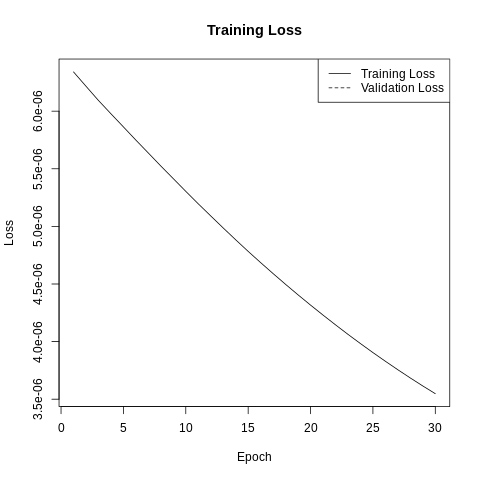

In [40]:
%%R

history_data <- history$history

plot(
  history_data$loss,
  type = "l",
  xlab = "Epoch",
  ylab = "Loss",
  main = "Training Loss"
)

lines(
  history_data$val_loss,
  lty = 2
)

legend(
  "topright",
  legend = c("Training Loss", "Validation Loss"),
  lty = c(1, 2)
)

In [42]:
%%R

# Recreate training data: 5 P images + 5 C images

trainx <- NULL

for(i in c(1:5, 7:11)) {
  trainx <- rbind(trainx, mypic[[i]])
}

print(dim(trainx))

[1]   10 2352


In [43]:
%%R

# Evaluation - Train Data

score <- model$evaluate(
  x = trainx,
  y = trainlabel
)

print(score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 7.7631
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 7.7631
[1] 7.763083 0.500000


In [44]:
%%R

# Prediction - Train Data

prediction <- model$predict(trainx)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
           [,1]         [,2]
 [1,] 0.9999999 6.642213e-20
 [2,] 0.9999999 2.149619e-20
 [3,] 0.9999999 2.907920e-19
 [4,] 0.9999999 1.697626e-10
 [5,] 0.9999999 2.619573e-14
 [6,] 0.9999999 7.342864e-14
 [7,] 0.9999999 6.142101e-14
 [8,] 0.9999999 9.303383e-13
 [9,] 1.0000000 1.973981e-14
[10,] 1.0000000 4.493327e-16


In [45]:
%%R

# Evaluation - Test Data

test_score <- model$evaluate(
  x = testx,
  y = testlabel
)

print(test_score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 7.5234
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 7.5234
[1] 7.523422 0.500000
